# Anti-memorization experiment (full dataset)

Eighteen runs: six arms $\times$ three seeds (7, 17, 27), 20 epochs each on the full repaired cohort, using
the electrostatics-rung features of the feature ladder and the same frozen target split. Validation is on
12 held-out targets (14,155 decoys); **the test split was not evaluated**. Design and motivation are in
`ANTI_MEMORIZATION_FULL.md`.

| arm | change relative to A |
|---|---|
| A control | -- (fixed-weight objective, range weighting, combined pooling, dropout 0.3) |
| B detached | DockQ head on detached embeddings; only reconstruction trains the encoder |
| C adversary | training-target classifier behind gradient reversal (weight 0.1, DANN ramp) |
| D augment | edge dropout 0.1, node-feature masking 0.1, C$\alpha$ jitter 0.25 \AA{} on encoder inputs |
| E balanced + EMA | 256 decoys/target/epoch; EMA (0.999) weights validated and checkpointed |
| F combined | C + D + E |

The motivating problem: every feature-ladder run picked epoch 1--2 and validation DockQ MSE then rose to
$\sim$0.13. The question is which arm lowers the best validation MSE and keeps it from rising.

Every run validated every 2,000 optimizer steps and at each epoch end; the checkpoint is the best of those.
E and F use 26,880 graphs per epoch (vs. 127,807), so curves are plotted against **training graphs seen**,
not epochs. Figures use LaTeX Computer Modern, large labels, full borders and no titles. Spreads are sample
SD over three seeds; paired intervals are bootstraps over the 12 validation targets.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

GATE = Path.cwd() if (Path.cwd() / 'anti_memorization_full').is_dir() else Path.cwd() / 'gate_run'
ROOT = GATE / 'anti_memorization_full'
LADDER = GATE / 'feature_ladder_full'
EXPORT = GATE / 'anti_memorization_full_analysis'; EXPORT.mkdir(exist_ok=True)

ARMS = ['A_control', 'B_detached', 'C_adversary', 'D_augment', 'E_balanced_ema', 'F_combined']
SEEDS = [7, 17, 27]
ARM_LABEL = {'A_control': 'A control', 'B_detached': 'B detached', 'C_adversary': 'C adversary',
             'D_augment': 'D augment', 'E_balanced_ema': 'E balanced+EMA', 'F_combined': 'F combined'}
SHORT = {a: a[0] for a in ARMS}
ARM_COLOR = {'A_control': '#000000', 'B_detached': '#0072B2', 'C_adversary': '#D55E00',
             'D_augment': '#009E73', 'E_balanced_ema': '#CC79A7', 'F_combined': '#E69F00'}
BATCH = 16

mpl.rcParams.update({'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern Roman'],
    'mathtext.fontset': 'cm', 'axes.labelsize': 23, 'xtick.labelsize': 17, 'ytick.labelsize': 17,
    'legend.fontsize': 17, 'axes.spines.top': True, 'axes.spines.right': True, 'axes.linewidth': 1.1})

def save(fig, name):
    fig.savefig(EXPORT / (name + '.pdf'), bbox_inches='tight')
    fig.savefig(EXPORT / (name + '.png'), dpi=180, bbox_inches='tight')
    plt.show()

def run_dir(arm, seed):
    return ROOT / f'{arm}_seed{seed}'

steps, history, predictions, reports, train_dist = [], [], {}, [], {}
for arm in ARMS:
    for seed in SEEDS:
        d = run_dir(arm, seed)
        s = pd.read_csv(d / 'validation_steps.csv').assign(arm=arm, seed=seed); steps.append(s)
        h = pd.read_csv(d / 'loss_history.csv').assign(arm=arm, seed=seed); history.append(h)
        predictions[arm, seed] = pd.read_csv(d / 'validation_predictions.csv')
        reports.append(dict(arm=arm, seed=seed, **json.loads((d / 'prediction_metrics.json').read_text())['validation']))
        train_dist[arm, seed] = json.loads((d / 'dockq_training_distribution.json').read_text())
steps = pd.concat(steps, ignore_index=True)
history = pd.concat(history, ignore_index=True)
steps['graphs_seen_M'] = steps.global_step * BATCH / 1e6

# Checks: identical validation cohort/labels, identical training label profile, finished runs,
# and exported predictions equal to the best validation in validation_steps.csv.
reference = predictions['A_control', 7][['target_id', 'graph_name', 'true_target']]
for (arm, seed), p in predictions.items():
    if not (p.target_id.equals(reference.target_id) and p.graph_name.equals(reference.graph_name)
            and np.allclose(p.true_target, reference.true_target)):
        raise ValueError(f'{arm} seed {seed}: validation cohort or labels differ')
    if train_dist[arm, seed]['counts'] != train_dist['A_control', 7]['counts']:
        raise ValueError(f'{arm} seed {seed}: training label distribution differs')
    s = steps[(steps.arm == arm) & (steps.seed == seed)]
    if history[(history.arm == arm) & (history.seed == seed)].epoch.max() != 20:
        raise ValueError(f'{arm} seed {seed}: did not finish 20 epochs')
    mse = np.mean((p.predicted_target - p.true_target) ** 2)
    if not np.isclose(mse, s.val_target_mse.min(), rtol=1e-5, atol=1e-7):
        raise ValueError(f'{arm} seed {seed}: exported predictions are not the best validation')
n_train = sum(train_dist['A_control', 7]['counts'])
print(f'{len(predictions)} runs; identical validation cohort: {len(reference):,} decoys / '
      f'{reference.target_id.nunique()} targets; {n_train:,} training graphs.')
print('Exported predictions match the best step validation in every run.')

18 runs; identical validation cohort: 14,155 decoys / 12 targets; 127,807 training graphs.
Exported predictions match the best step validation in every run.


## Reference points

A constant predictor at the validation mean has MSE equal to the validation variance (an optimistic
no-skill baseline: it uses validation labels). The feature-ladder electrostatics rung used the same
features, cohort and split but a different recipe (below); its validation history is logged once per
epoch.

In [2]:
CONST_MSE = reference.true_target.var(ddof=0)
lad = pd.concat([pd.read_csv(LADDER / f'gat4_residual_electrostatics_seed{s}' / 'loss_history.csv').assign(seed=s)
                 for s in SEEDS], ignore_index=True)
lad['graphs_seen_M'] = lad.epoch * n_train / 1e6
lad_best = lad.groupby('seed').val_target_mse.min()
lad_final = lad[lad.epoch == lad.epoch.max()].set_index('seed').val_target_mse
print(f'Constant-predictor validation MSE: {CONST_MSE:.4f}')
print(f'Feature ladder (electrostatics): best {lad_best.mean():.4f} +/- {lad_best.std():.4f}, '
      f'final (epoch 50) {lad_final.mean():.4f} +/- {lad_final.std():.4f}')

Constant-predictor validation MSE: 0.0903
Feature ladder (electrostatics): best 0.0716 +/- 0.0129, final (epoch 50) 0.1305 +/- 0.0056


## Per-run metrics

From `validation_steps.csv` (every validation) and the checkpoint's `validation_predictions.csv`.
**best** is the selected validation MSE; **final** is the last validation of training; **after best** is the
median of all validations from the best step onward (how well the gain persists). Macro metrics weight the
12 targets equally; $\rho$ is within-target Spearman; top-1 is the true DockQ of each target's top-ranked
decoy.

In [3]:
def target_metrics(g):
    y = g.true_target.to_numpy(); p = g.predicted_target.to_numpy()
    order = np.lexsort((g.graph_name.to_numpy(), -p))
    return pd.Series(dict(mse=np.mean((p - y) ** 2), rho=spearmanr(y, p).statistic, top1=y[order[0]],
                          top5=y[order[:5]].max(), best=y.max()))

per_target, rows = [], []
for (arm, seed), p in predictions.items():
    t = p.groupby('target_id')[['graph_name', 'true_target', 'predicted_target']].apply(target_metrics)
    per_target.append(t.reset_index().assign(arm=arm, seed=seed))
    s = steps[(steps.arm == arm) & (steps.seed == seed)].sort_values('global_step')
    b = s.loc[s.val_target_mse.idxmin()]
    rep = next(r for r in reports if r['arm'] == arm and r['seed'] == seed)
    rows.append(dict(arm=arm, seed=seed, best=b.val_target_mse, best_epoch=int(b.epoch),
                     best_graphs_M=b.graphs_seen_M, final=s.val_target_mse.iloc[-1],
                     after_best=s[s.global_step >= b.global_step].val_target_mse.median(),
                     macro_mse=t.mse.mean(), macro_rho=t.rho.mean(), top1=t.top1.mean(), top5=t.top5.mean(),
                     high_bias=rep['bins'][4]['bias'], low_bias=rep['bins'][0]['bias'],
                     macro_bin_mse=rep['macro_bin_mse']))
per_target = pd.concat(per_target, ignore_index=True)
metrics = pd.DataFrame(rows)
metrics['final_over_best'] = metrics.final / metrics.best
metrics.to_csv(EXPORT / 'metrics_per_run.csv', index=False)
per_target.to_csv(EXPORT / 'metrics_per_target.csv', index=False)
display(metrics.round(4))

cols = ['best', 'final', 'after_best', 'final_over_best', 'best_epoch', 'macro_mse', 'macro_rho', 'top1',
        'high_bias', 'low_bias']
agg = metrics.groupby('arm')[cols].agg(['mean', 'std']).loc[ARMS]
agg.to_csv(EXPORT / 'metrics_by_arm.csv')
display(agg.round(4))

,arm,seed,best,best_epoch,best_graphs_M,final,after_best,macro_mse,macro_rho,top1,top5,high_bias,low_bias,macro_bin_mse,final_over_best
0,A_control,7,0.0488,10,1.1520,0.0550,0.0541,0.0517,0.7241,0.5642,0.7100,-0.3242,0.1552,0.0609,1.1273
1,A_control,17,0.0468,11,1.3760,0.0488,0.0491,0.0499,0.7123,0.5030,0.7141,-0.2816,0.1520,0.0568,1.0420
2,A_control,27,0.0498,7,0.7680,0.0574,0.0560,0.0530,0.6989,0.5035,0.6491,-0.3172,0.1510,0.0614,1.1523
3,B_detached,7,0.0553,18,2.2400,0.0564,0.0560,0.0557,0.6592,0.3803,0.7655,-0.3244,0.1865,0.0600,1.0194
4,B_detached,17,0.0550,5,0.5120,0.0605,0.0607,0.0557,0.7078,0.3833,0.6605,-0.3074,0.2056,0.0561,1.0985
5,B_detached,27,0.0606,7,0.8947,0.0653,0.0649,0.0615,0.6416,0.4712,0.6384,-0.3820,0.1528,0.0748,1.0773
6,C_adversary,7,0.0528,3,0.2560,0.0984,0.0989,0.0537,0.6814,0.4353,0.7129,-0.3649,0.1711,0.0643,1.8638
7,C_adversary,17,0.0537,3,0.2560,0.0991,0.0990,0.0559,0.6783,0.4191,0.7222,-0.3372,0.1576,0.0668,1.8464
8,C_adversary,27,0.0485,3,0.2880,0.0985,0.0989,0.0501,0.7019,0.4598,0.7127,-0.2972,0.1430,0.0588,2.0316
9,D_augment,7,0.0474,7,0.8320,0.0569,0.0555,0.0492,0.7209,0.6068,0.7677,-0.3237,0.1435,0.0587,1.1986


best           final         after_best           \
                  mean     std    mean     std       mean      std   
arm                                                                  
A_control       0.0485  0.0015  0.0537  0.0044     0.0531   0.0036   
B_detached      0.0570  0.0032  0.0607  0.0045     0.0606   0.0045   
C_adversary     0.0516  0.0028  0.0987  0.0004     0.0989   0.0001   
D_augment       0.0504  0.0029  0.0611  0.0049     0.0586   0.0030   
E_balanced_ema  0.0524  0.0003  0.0539  0.0020     0.0537   0.0016   
F_combined      0.0530  0.0014  0.0652  0.0206     6.6536  11.4324   

               final_over_best         best_epoch         macro_mse          \
                          mean     std       mean     std      mean     std   
arm                                                                           
A_control               1.1072  0.0578     9.3333  2.0817    0.0515  0.0016   
B_detached              1.0651  0.0409    10.0000  7.0000    0.0576  0.0033   
C_adversary             1.9139  0.1023     3.0000  0.0000    0.0532  0.0029   
D_augment               1.2132  0.0953     5.0000  1.7321    0.0528  0.0035   
E_balanced_ema          1.0295  0.0445    12.6667  8.7369    0.0538  0.0005   
F_combined              1.2249  0.3637    13.3333  5.8595    0.0543  0.0010   

               macro_rho            top1         high_bias         low_bias  \
                    mean     std    mean     std      mean     std     mean   
arm                                                                           
A_control         0.7118  0.0126  0.5236  0.0352   -0.3077  0.0228   0.1527   
B_detached        0.6695  0.0343  0.4116  0.0516   -0.3379  0.0391   0.1816   
C_adversary       0.6872  0.0129  0.4381  0.0205   -0.3331  0.0340   0.1572   
D_augment         0.7047  0.0140  0.4781  0.1222   -0.3517  0.0274   0.1397   
E_balanced_ema    0.6851  0.0178  0.4518  0.0602   -0.3455  0.0092   0.1762   
F_combined        0.6862  0.0032  0.5195  0.0658   -0.3726  0.0202   0.1837   

                        
                   std  
arm                     
A_control       0.0022  
B_detached      0.0267  
C_adversary     0.0141  
D_augment       0.0084  
E_balanced_ema  0.0014  
F_combined      0.0141

## Headline: best and end-of-training validation MSE

Solid bars: best (selected) validation MSE; hatched bars: final validation of training. Dots are seeds; error
bars are seed SD. Dashed line: constant predictor. Dotted line: feature-ladder electrostatics best (mean of 3
seeds). F seed 7 and all three C runs diverged late in training (next sections); their final values sit at
the constant predictor.

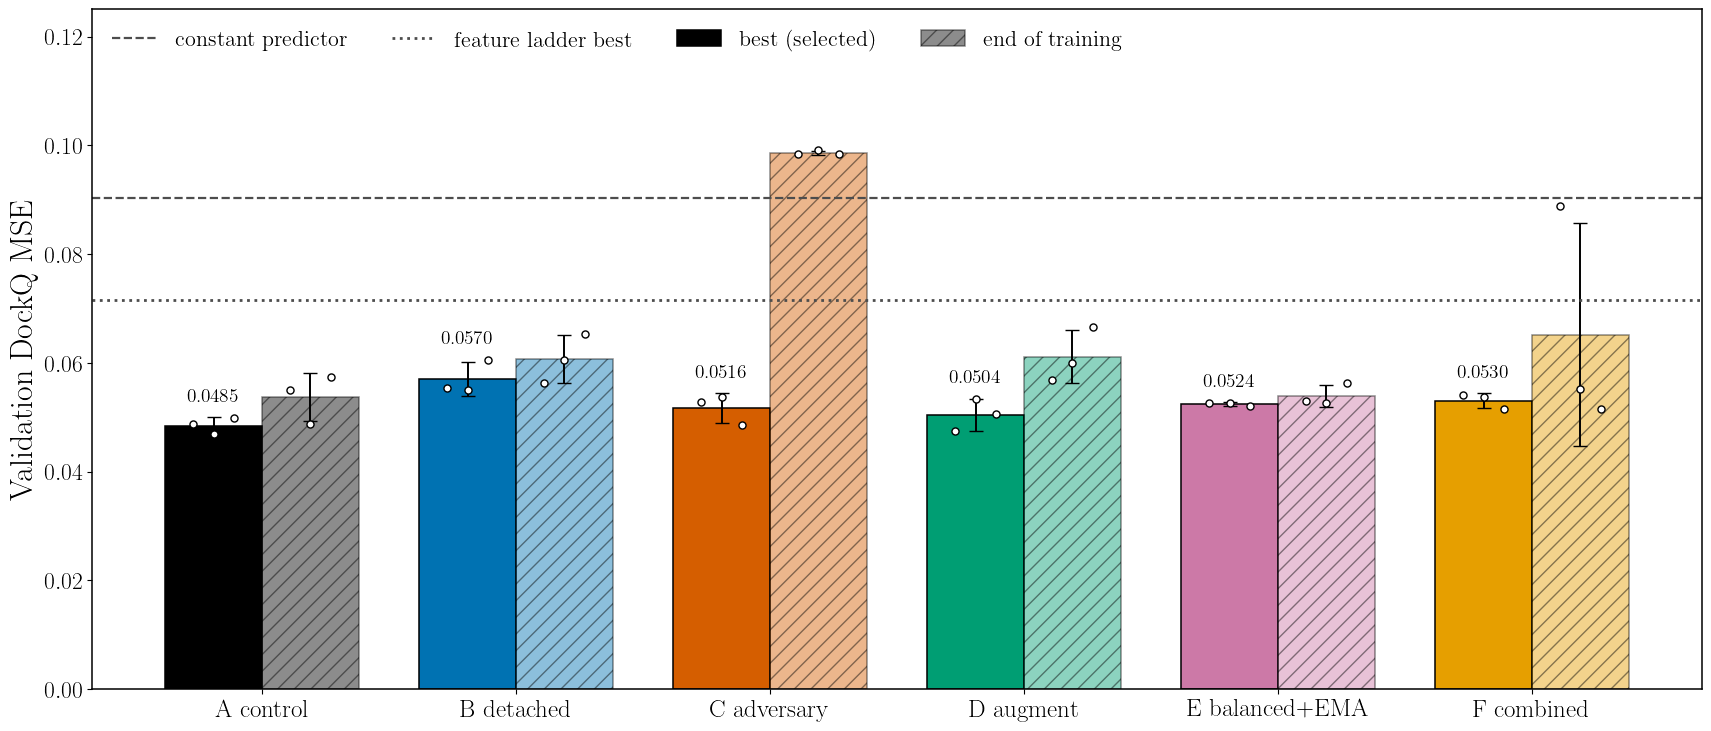

In [4]:
fig, ax = plt.subplots(figsize=(17, 7.2), constrained_layout=True)
x = np.arange(len(ARMS)); w = .38
for k, (col, hatch, alpha) in enumerate([('best', None, 1.0), ('final', '//', .45)]):
    v = agg[(col, 'mean')].to_numpy(); e = agg[(col, 'std')].to_numpy()
    ax.bar(x + (k - .5) * w, v, w, yerr=e, capsize=5, color=[ARM_COLOR[a] for a in ARMS], alpha=alpha,
           hatch=hatch, edgecolor='black', lw=1.1, error_kw=dict(lw=1.4),
           label='best (selected)' if col == 'best' else 'end of training')
    for i, a in enumerate(ARMS):
        sv = metrics.loc[metrics.arm == a, col].to_numpy()
        ax.scatter(x[i] + (k - .5) * w + np.linspace(-.08, .08, 3), sv, s=26, zorder=6,
                   facecolors='white', edgecolors='black', linewidths=1)
        if col == 'best':
            ax.text(x[i] + (k - .5) * w, max(v[i] + e[i], sv.max()) + .003, f'{v[i]:.4f}', ha='center',
                    fontsize=14, bbox=dict(facecolor='white', edgecolor='none', pad=1), zorder=7)
ax.axhline(CONST_MSE, color='0.3', ls='--', lw=1.6, label='constant predictor')
ax.axhline(lad_best.mean(), color='0.3', ls=':', lw=2, label='feature ladder best')
ax.set_xticks(x, [ARM_LABEL[a] for a in ARMS], fontsize=18)
ax.set_ylabel('Validation DockQ MSE'); ax.set_ylim(0, .125)
ax.legend(frameon=False, loc='upper left', ncol=4, fontsize=16)
save(fig, 'best_and_final_mse')

## Validation curves against training graphs seen

Each panel: one arm's three seeds (thin) and their mean (thick); the control's mean is repeated in grey on
every panel. Panel A also shows the feature ladder (electrostatics rung, one point per epoch, first 2.6M
graphs). The y-axis is capped at 0.11; values above it (C and F seed 7 divergence) are clipped at the top
edge.

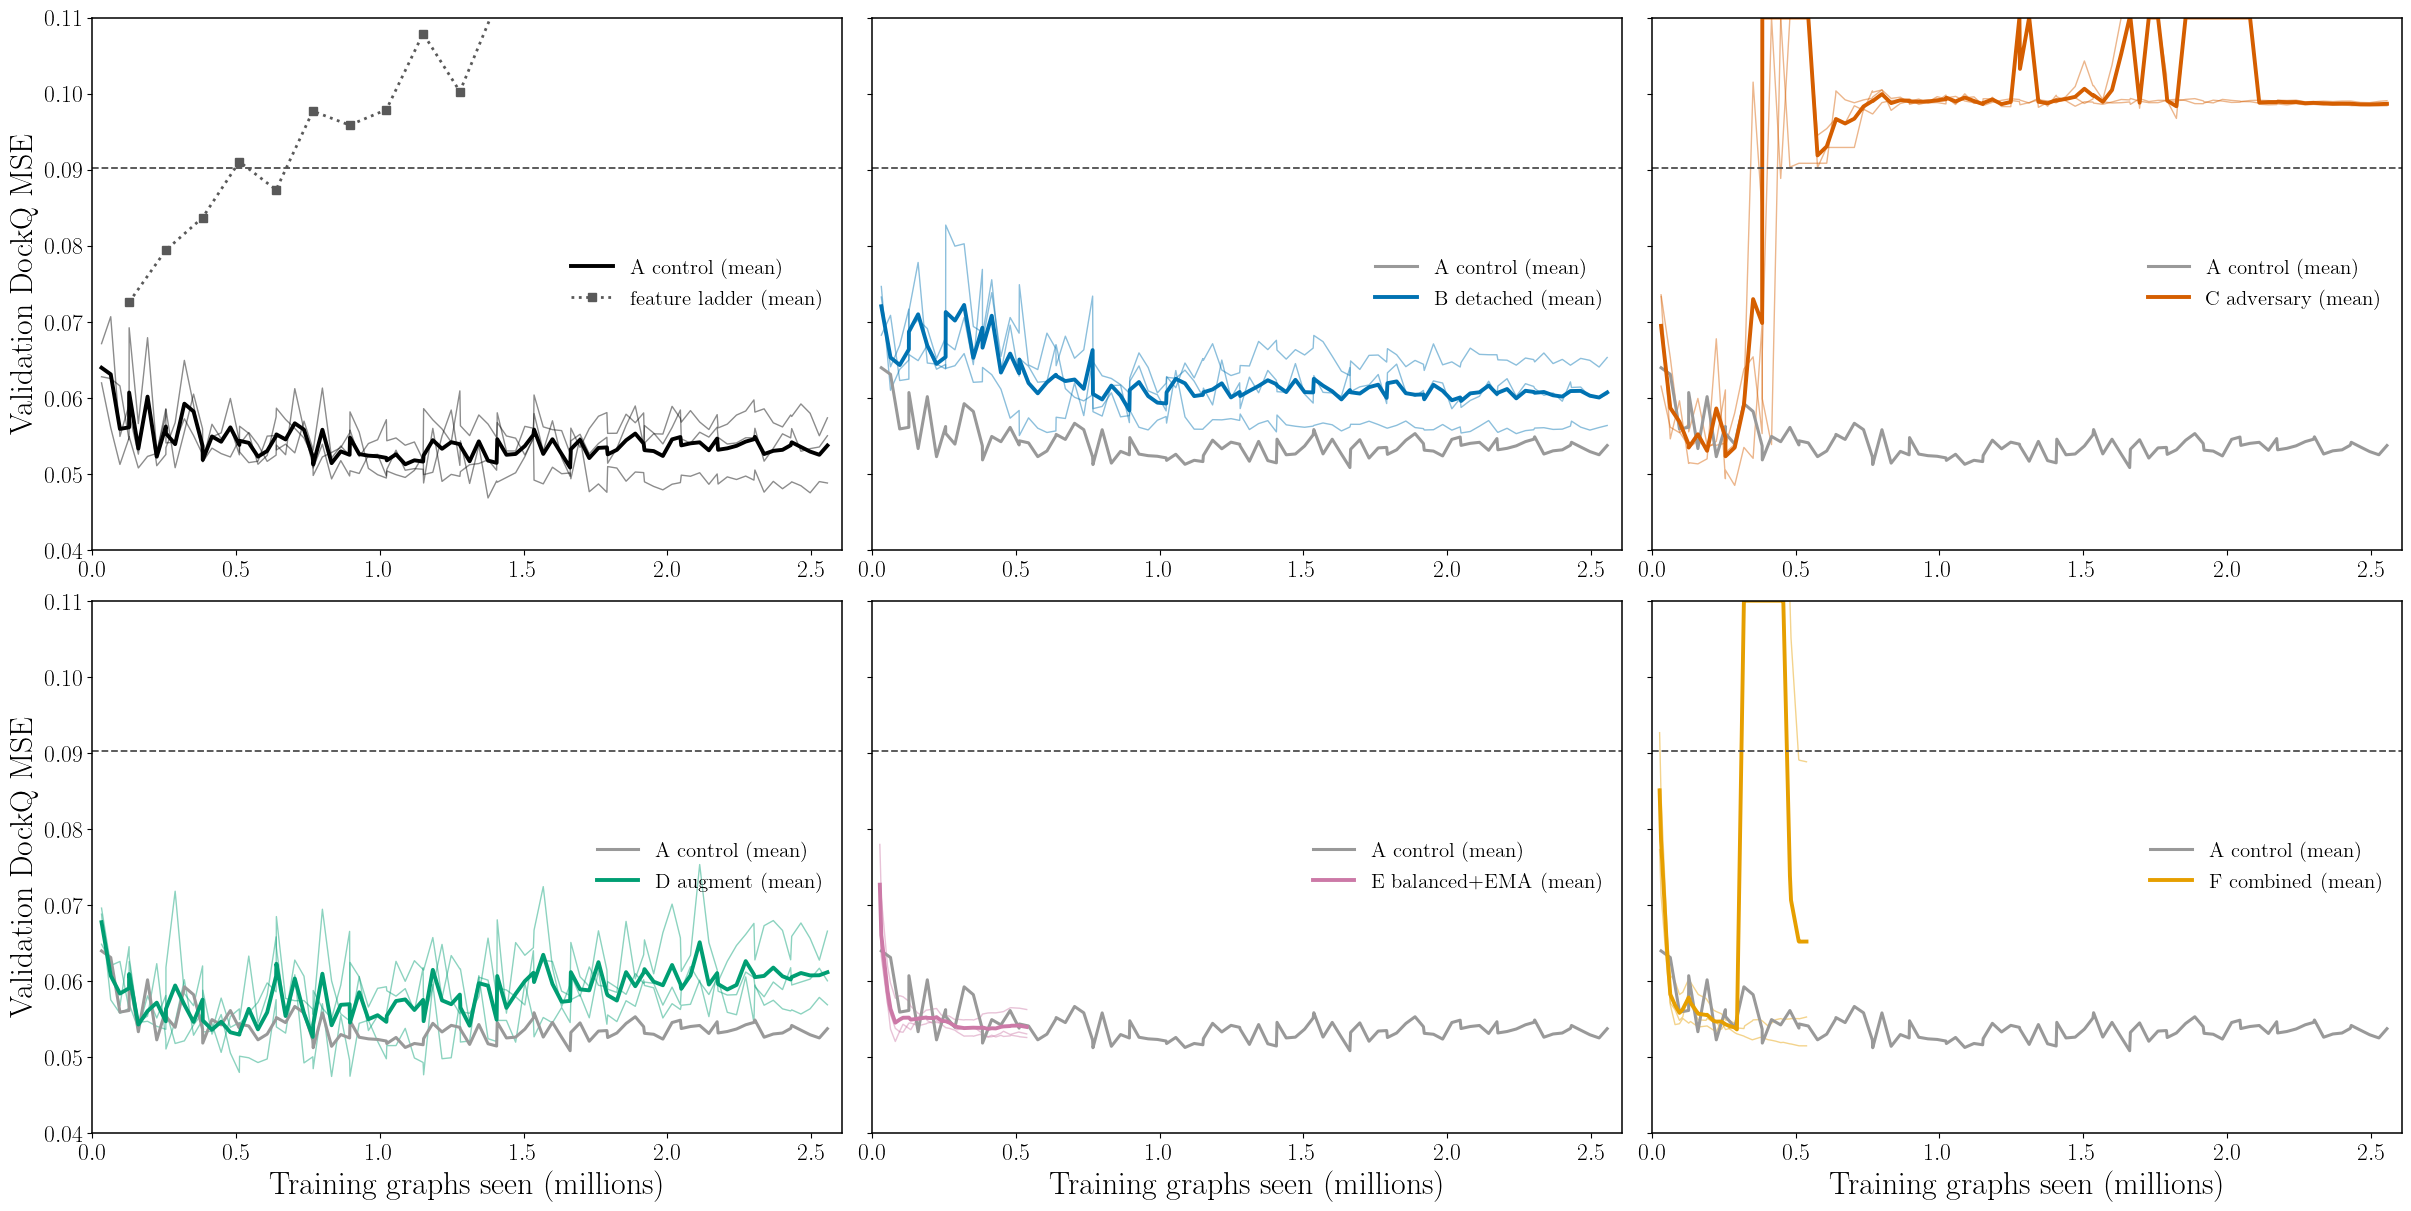

In [5]:
YMAX = .11
ctrl = steps[steps.arm == 'A_control'].groupby('global_step').agg(x=('graphs_seen_M', 'first'),
                                                                   y=('val_target_mse', 'mean'))
fig, axes = plt.subplots(2, 3, figsize=(24, 12), sharey=True, constrained_layout=True)
for ax, arm in zip(axes.flat, ARMS):
    for seed in SEEDS:
        s = steps[(steps.arm == arm) & (steps.seed == seed)].sort_values('global_step')
        ax.plot(s.graphs_seen_M, s.val_target_mse.clip(upper=YMAX), color=ARM_COLOR[arm], lw=1, alpha=.45)
    m = steps[steps.arm == arm].groupby('global_step').agg(x=('graphs_seen_M', 'first'), y=('val_target_mse', 'mean'))
    if arm != 'A_control':
        ax.plot(ctrl.x, ctrl.y, color='0.6', lw=2.2, label='A control (mean)')
    ax.plot(m.x, m.y.clip(upper=YMAX), color=ARM_COLOR[arm], lw=2.8, label=ARM_LABEL[arm] + ' (mean)')
    if arm == 'A_control':
        lg = lad.groupby('epoch').agg(x=('graphs_seen_M', 'first'), y=('val_target_mse', 'mean'))
        lg = lg[lg.x <= ctrl.x.max()]
        ax.plot(lg.x, lg.y, color='0.35', ls=':', marker='s', ms=6, lw=2, label='feature ladder (mean)')
    ax.axhline(CONST_MSE, color='0.3', ls='--', lw=1.3)
    ax.set_ylim(.04, YMAX); ax.set_xlim(0, ctrl.x.max() * 1.02)
    ax.legend(frameon=False, loc='center right', fontsize=15)
for ax in axes[-1]: ax.set_xlabel('Training graphs seen (millions)')
for ax in axes[:, 0]: ax.set_ylabel('Validation DockQ MSE')
save(fig, 'validation_curves_by_arm')

## The control vs the feature ladder

Same features, cohort and split. Left: validation DockQ MSE (seed mean $\pm$ SD) against graphs seen.
Right: training DockQ MSE on a log scale. **Not a controlled comparison.** The control changed several things
at once relative to the ladder, so the improvement cannot be attributed to any single one:

| setting | feature ladder | A control |
|---|---|---|
| loss weighting | adaptive shares (DockQ weight 14 $\to$ 260) | fixed: DockQ $+ 1\times$ reconstruction |
| DockQ range weighting | none | capped inverse-sqrt ($\alpha$ 0.5) |
| pooling | whole graph | whole graph + interface |
| dropout | 0.1 | 0.3 |
| schedule | 50-epoch cosine | 20-epoch cosine (LR decays 2.5$\times$ faster per epoch) |
| checkpoint resolution | once per epoch | every 2,000 steps |
| validation MSE | batch-averaged | exact graph-averaged |

Training DockQ MSE for the control is range-weighted (mean weight 1) while the ladder's is unweighted; the
difference is small next to the order-of-magnitude gap.

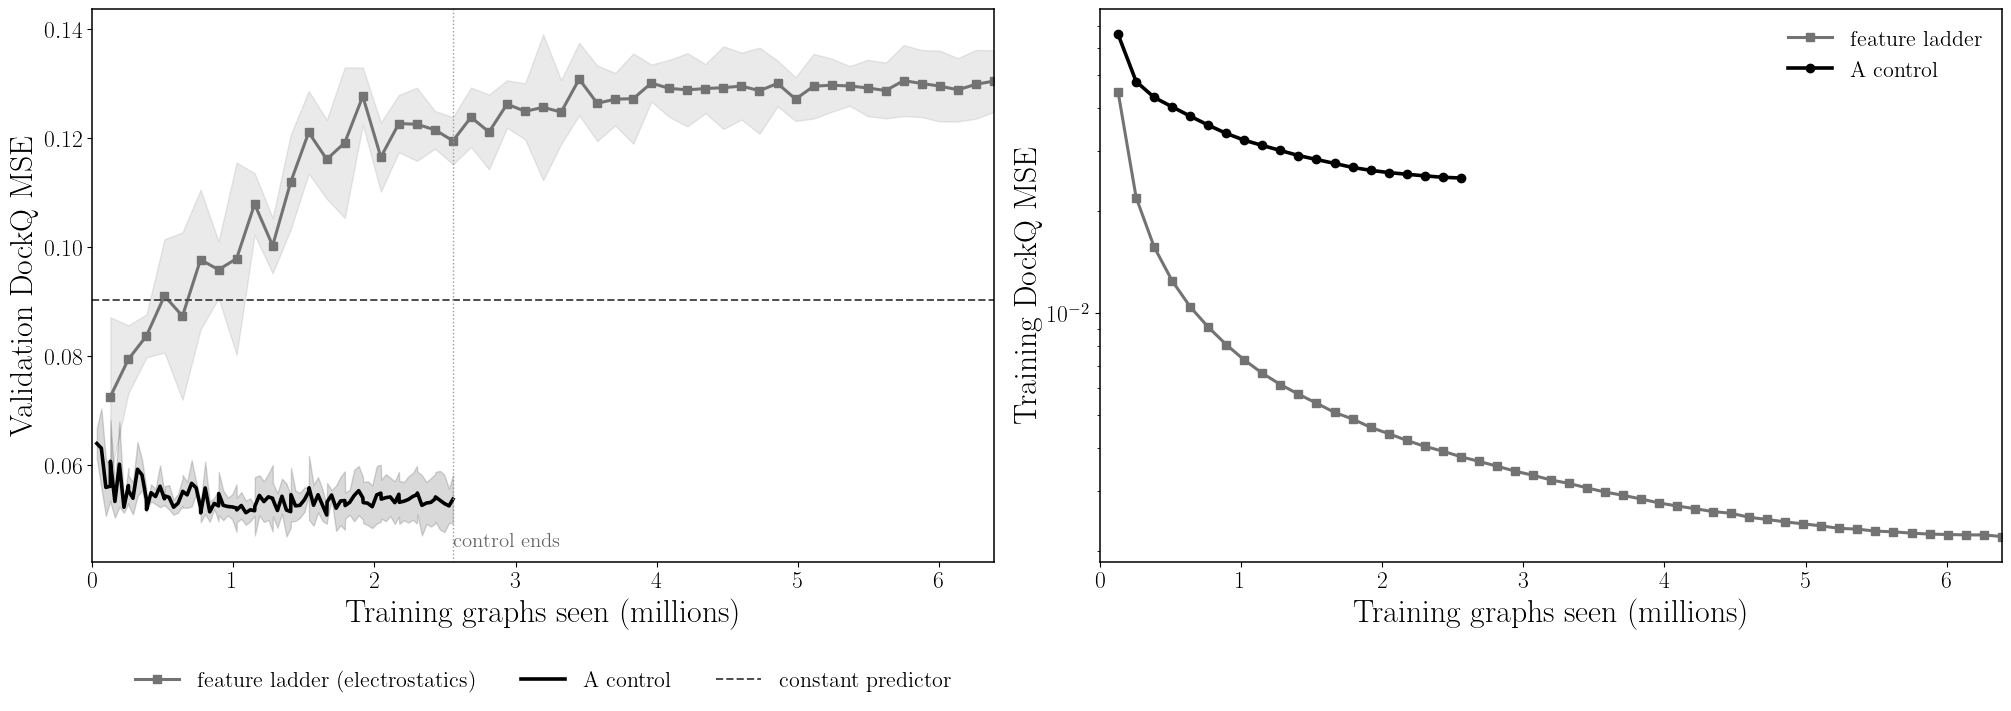

Training DockQ MSE at the last epoch: control 0.0250, ladder at epoch 20 0.0038, at epoch 50 0.0022


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), constrained_layout=True)
xmax = 20 * n_train / 1e6
lg = lad.groupby('epoch').agg(x=('graphs_seen_M', 'first'), m=('val_target_mse', 'mean'), s=('val_target_mse', 'std'),
                              tm=('train_target_mse', 'mean'))
a = steps[steps.arm == 'A_control'].groupby('global_step').agg(x=('graphs_seen_M', 'first'),
        m=('val_target_mse', 'mean'), s=('val_target_mse', 'std'))
ax = axes[0]
ax.plot(lg.x, lg.m, color='0.45', marker='s', ms=6, lw=2.2, label='feature ladder (electrostatics)')
ax.fill_between(lg.x, lg.m - lg.s, lg.m + lg.s, color='0.45', alpha=.15)
ax.plot(a.x, a.m, color='black', lw=2.6, label='A control')
ax.fill_between(a.x, a.m - a.s, a.m + a.s, color='black', alpha=.15)
ax.axhline(CONST_MSE, color='0.3', ls='--', lw=1.4, label='constant predictor')
ax.set_xlim(0, lad.graphs_seen_M.max()); ax.set_xlabel('Training graphs seen (millions)')
ax.set_ylabel('Validation DockQ MSE'); ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(.5, -.16), ncol=3, fontsize=16)
ax.axvline(xmax, color='0.6', lw=1, ls=':')
ax.text(xmax, .045, ' control ends', fontsize=15, color='0.4')

ax = axes[1]
ha = history[history.arm == 'A_control'].groupby('epoch').train_target_mse.mean()
ax.plot(lg.x, lg.tm, color='0.45', marker='s', ms=6, lw=2.2, label='feature ladder')
ax.plot(ha.index * n_train / 1e6, ha.values, color='black', marker='o', ms=6, lw=2.6, label='A control')
ax.set_yscale('log'); ax.set_xlim(0, lad.graphs_seen_M.max())
ax.set_xlabel('Training graphs seen (millions)'); ax.set_ylabel('Training DockQ MSE')
ax.legend(frameon=False, loc='upper right', fontsize=16)
save(fig, 'control_vs_feature_ladder')
print(f"Training DockQ MSE at the last epoch: control {ha.iloc[-1]:.4f}, ladder at epoch 20 "
      f"{lad[lad.epoch == 20].train_target_mse.mean():.4f}, at epoch 50 {lad[lad.epoch == 50].train_target_mse.mean():.4f}")

## Each arm against the control, paired by target

For every validation target, the arm's MSE (or within-target $\rho$) is averaged over seeds and differenced
against the control's; the 12 differences are bootstrapped (10,000 resamples) for a 95% interval. Positive
values favour the arm in both panels. Numbers on the right count the targets where the arm beat the control.

,arm,metric,mean,lo,hi,wins,n
0,B_detached,mse,-0.0061,-0.0151,0.0041,3,12
1,B_detached,rho,-0.0423,-0.0858,0.0215,1,12
2,B_detached,top1,-0.1120,-0.2691,0.0555,4,12
3,C_adversary,mse,-0.0017,-0.0098,0.0069,4,12
4,C_adversary,rho,-0.0245,-0.0608,0.0179,2,12
5,C_adversary,top1,-0.0855,-0.2146,0.0193,3,12
6,D_augment,mse,-0.0013,-0.0061,0.0031,4,12
7,D_augment,rho,-0.0070,-0.0331,0.0221,4,12
8,D_augment,top1,-0.0454,-0.1778,0.0552,6,12
9,E_balanced_ema,mse,-0.0022,-0.0088,0.0059,3,12


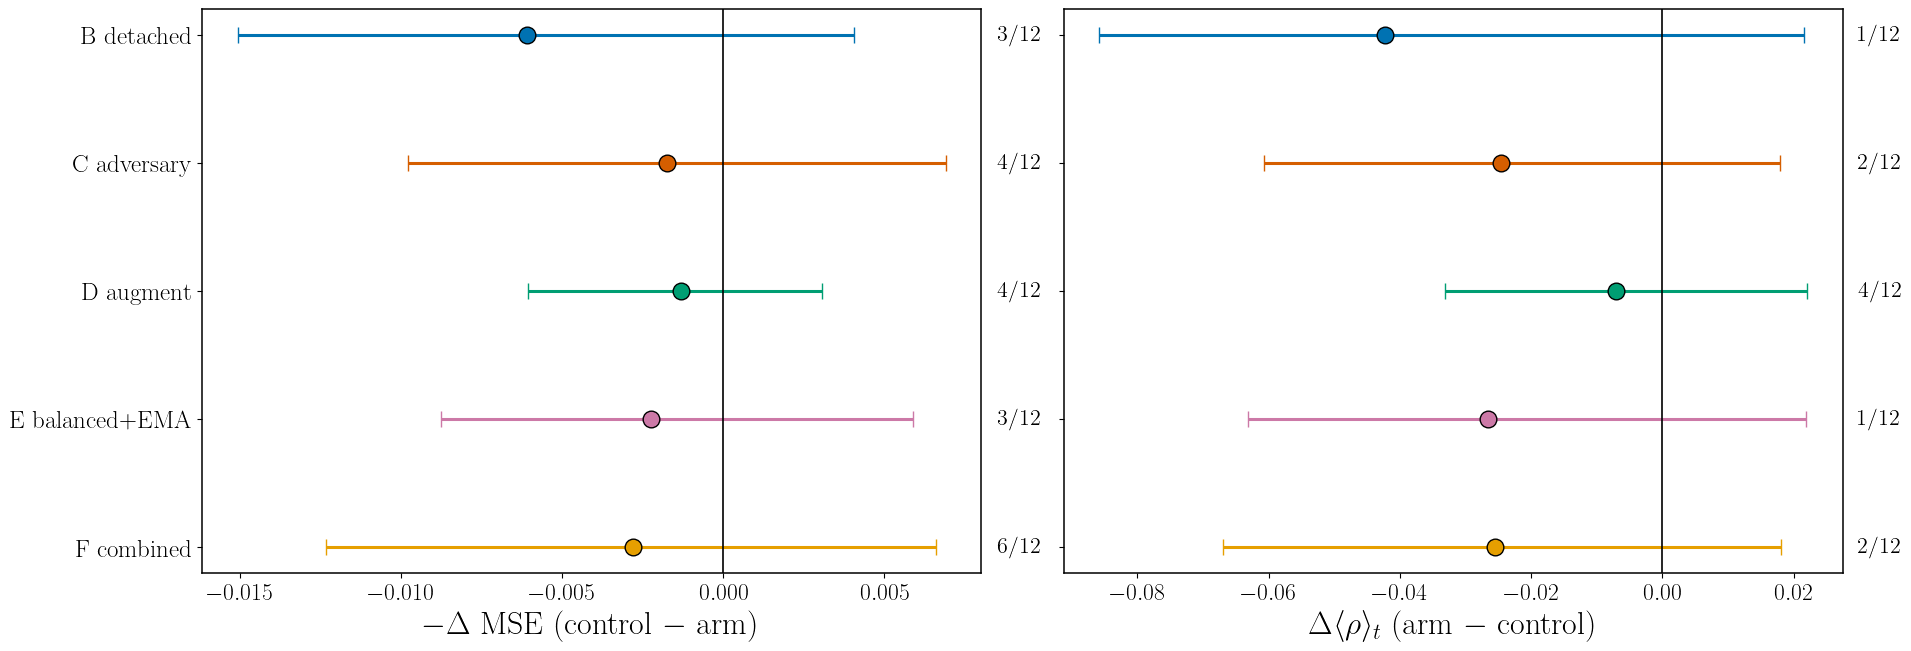

In [7]:
rng = np.random.default_rng(0)
seed_mean = per_target.groupby(['arm', 'target_id'])[['mse', 'rho', 'top1']].mean()
eff = []
for arm in ARMS[1:]:
    for metric, sign in [('mse', -1), ('rho', 1), ('top1', 1)]:
        d = sign * (seed_mean.loc[arm, metric] - seed_mean.loc['A_control', metric]).to_numpy()
        boots = rng.choice(d, size=(10_000, len(d))).mean(1)
        eff.append(dict(arm=arm, metric=metric, mean=d.mean(), lo=np.percentile(boots, 2.5),
                        hi=np.percentile(boots, 97.5), wins=int((d > 0).sum()), n=len(d)))
eff = pd.DataFrame(eff); eff.to_csv(EXPORT / 'paired_vs_control.csv', index=False)
display(eff.round(4))

fig, axes = plt.subplots(1, 2, figsize=(19, 6.4), sharey=True, constrained_layout=True)
yp = np.arange(len(ARMS) - 1)[::-1]
for ax, metric, xlabel in [(axes[0], 'mse', r'$-\Delta$ MSE (control $-$ arm)'),
                           (axes[1], 'rho', r'$\Delta\langle\rho\rangle_t$ (arm $-$ control)')]:
    e = eff[eff.metric == metric].set_index('arm').loc[ARMS[1:]]
    for yv, (arm, r) in zip(yp, e.iterrows()):
        ax.errorbar(r['mean'], yv, xerr=[[r['mean'] - r.lo], [r.hi - r['mean']]], fmt='o', ms=12, capsize=6,
                    lw=2.2, color=ARM_COLOR[arm], mec='black')
        ax.text(1.02, yv, f'{r.wins}/{r.n}', transform=ax.get_yaxis_transform(), va='center', fontsize=16)
    ax.axvline(0, color='black', lw=1.2); ax.set_xlabel(xlabel)
axes[0].set_yticks(yp, [ARM_LABEL[a] for a in ARMS[1:]], fontsize=18)
save(fig, 'paired_vs_control')

## What happened to the adversary (C, and F)

Training loss terms by epoch for the adversary runs. The reversed gradient asks the encoder to *maximize*
the adversary's cross-entropy, which is unbounded. Once the DANN coefficient passed $\sim$0.5 (epoch 3), the
encoder in all three C runs found it could inflate the cross-entropy by blowing up its activations: CE rose
to $10^{4}$--$10^{6}$, training DockQ MSE exploded, and validation MSE settled at the constant-predictor level.
F (with augmentation and EMA) held out until epoch 12 for seed 7 and not at all for seeds 17 and 27. The
early validation numbers for C are real (they are from before the collapse), but the method as configured is
unstable.

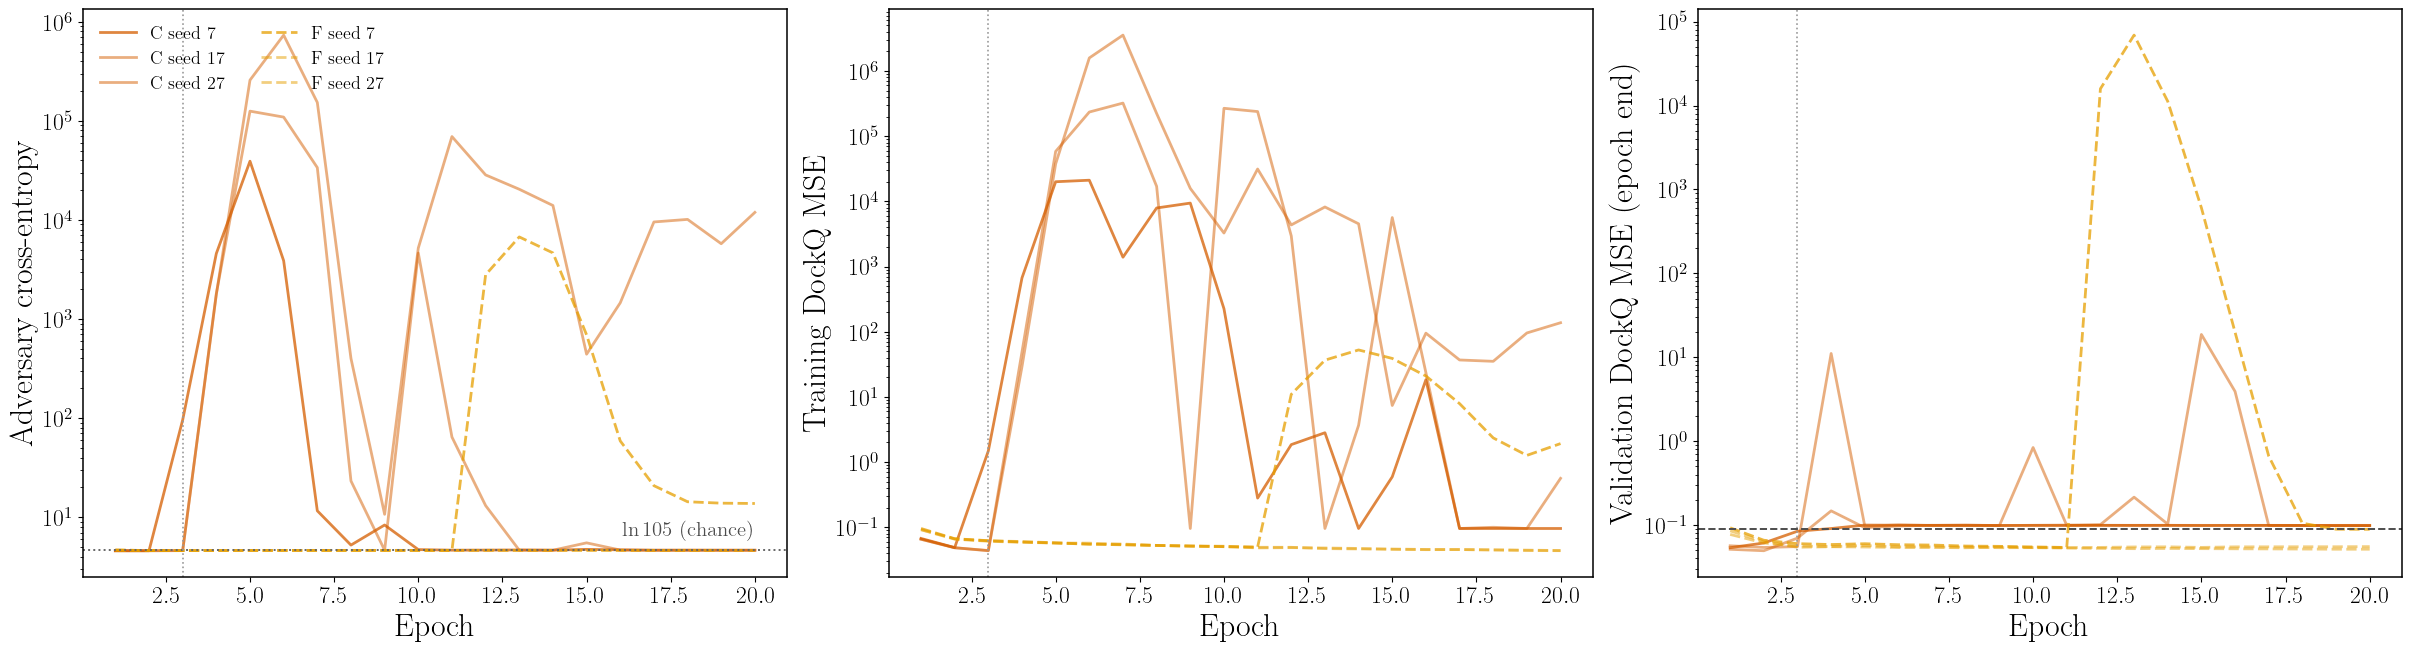

DANN coefficient by epoch: {1: 0.124, 2: 0.357, 3: 0.553, 4: 0.702, 5: 0.808, 6: 0.879, 7: 0.925, 8: 0.954, 9: 0.972, 10: 0.983, 11: 0.989, 12: 0.994, 13: 0.996, 14: 0.998, 15: 0.999, 16: 0.999, 17: 0.999, 18: 1.0, 19: 1.0, 20: 1.0}


In [8]:
adv = history[history.arm.isin(['C_adversary', 'F_combined'])]
fig, axes = plt.subplots(1, 3, figsize=(24, 6.4), constrained_layout=True)
for (arm, seed), h in adv.groupby(['arm', 'seed']):
    ls = '-' if arm == 'C_adversary' else '--'
    lab = f"{SHORT[arm]} seed {seed}"
    axes[0].plot(h.epoch, h.train_target_adversary_ce, ls, color=ARM_COLOR[arm], lw=2, alpha=.5 + .25 * (seed == 7), label=lab)
    axes[1].plot(h.epoch, h.train_target_mse, ls, color=ARM_COLOR[arm], lw=2, alpha=.5 + .25 * (seed == 7))
    axes[2].plot(h.epoch, h.val_target_mse, ls, color=ARM_COLOR[arm], lw=2, alpha=.5 + .25 * (seed == 7))
coef = adv.groupby('epoch').train_target_adversary_coefficient.mean()
axes[0].axhline(np.log(105), color='0.4', ls=':', lw=1.4)
axes[0].text(20, np.log(105) * 1.4, r'$\ln 105$ (chance)', ha='right', fontsize=15, color='0.3')
for ax, lab in zip(axes, ['Adversary cross-entropy', 'Training DockQ MSE', 'Validation DockQ MSE (epoch end)']):
    ax.set_yscale('log'); ax.set_xlabel('Epoch'); ax.set_ylabel(lab)
    ax.axvline(coef[coef >= .5].index.min(), color='0.6', ls=':', lw=1.2)
axes[2].axhline(CONST_MSE, color='0.3', ls='--', lw=1.4)
axes[0].legend(frameon=False, fontsize=13, ncol=2, loc='upper left')
save(fig, 'adversary_instability')
print('DANN coefficient by epoch:', coef.round(3).to_dict())

## Training vs validation: is memorization reduced?

End-of-training training DockQ MSE (range-weighted, comparable across arms because every arm uses the same
weights) against the best validation MSE. Arms further right fit the training targets less tightly. Runs
that diverged (all three C runs and F seed 7, whose end-of-training validation MSE is above 0.08) are omitted.

The relationship runs the opposite way to the memorization hypothesis: the arms that fit training DockQ
*less* tightly (B, F, E) also have *higher* validation MSE. Restraining the fit mostly cost accuracy rather
than buying generalization. Under this recipe, remaining error looks more like underfitting/limited
signal than like memorization.

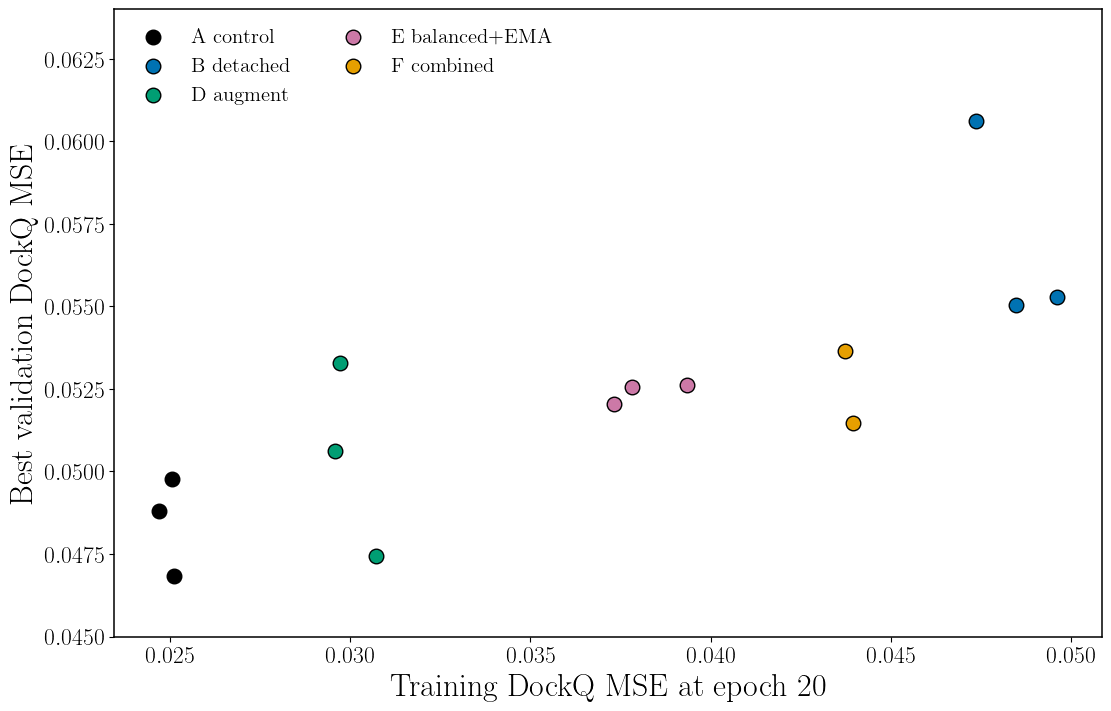

,arm,seed,train_target_mse,best,diverged
0,A_control,7,0.0247,0.0488,False
1,A_control,17,0.0251,0.0468,False
2,A_control,27,0.0251,0.0498,False
3,B_detached,7,0.0496,0.0553,False
4,B_detached,17,0.0485,0.0550,False
5,B_detached,27,0.0474,0.0606,False
6,C_adversary,7,0.0958,0.0528,True
7,C_adversary,17,0.5631,0.0537,True
8,C_adversary,27,137.3920,0.0485,True
9,D_augment,7,0.0307,0.0474,False


In [9]:
end = history[history.epoch == 20][['arm', 'seed', 'train_target_mse']].merge(metrics[['arm', 'seed', 'best']])
end['diverged'] = end.merge(metrics[['arm', 'seed', 'final']]).final.to_numpy() > .08
fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)
for arm in ARMS:
    e = end[(end.arm == arm) & ~end.diverged]
    if e.empty:
        continue
    ax.scatter(e.train_target_mse, e.best, s=110, color=ARM_COLOR[arm], edgecolors='black', label=ARM_LABEL[arm],
               zorder=5)
ax.axhline(CONST_MSE, color='0.3', ls='--', lw=1.4)
ax.set_xlabel('Training DockQ MSE at epoch 20'); ax.set_ylabel('Best validation DockQ MSE')
ax.set_ylim(.045, .064)
ax.legend(frameon=False, fontsize=15, loc='upper left', ncol=2)
save(fig, 'train_vs_validation')
display(end.round(4))

## Score range: where does each arm err?

Mean prediction error (bias) and MSE by true-DockQ bin at the selected checkpoint, averaged over seeds.
Every arm still over-predicts poor decoys and under-predicts high-quality ones (score compression). The
control has the smallest under-prediction in the 0.8--1 bin, and the lowest MSE there.

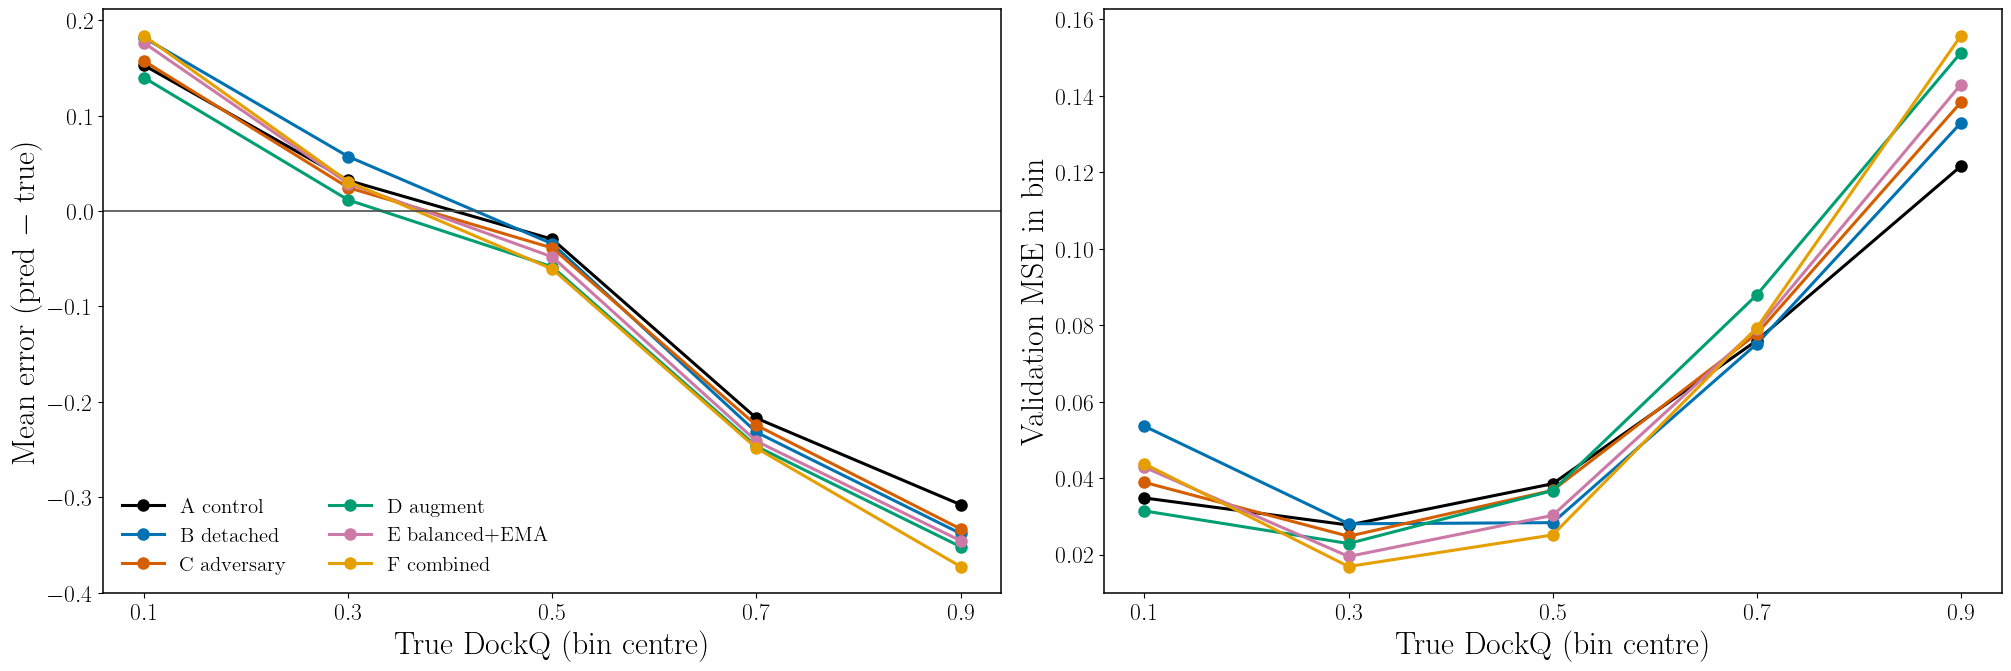

In [10]:
bins = pd.DataFrame([dict(arm=r['arm'], seed=r['seed'], **b) for r in reports for b in r['bins']])
bins['mid'] = (bins.low + bins.high) / 2
bm = bins.groupby(['arm', 'mid'])[['bias', 'mse']].mean().reset_index()
bm.to_csv(EXPORT / 'bins_by_arm.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(20, 6.6), constrained_layout=True)
for arm in ARMS:
    b = bm[bm.arm == arm]
    axes[0].plot(b.mid, b.bias, marker='o', ms=8, lw=2.2, color=ARM_COLOR[arm], label=ARM_LABEL[arm])
    axes[1].plot(b.mid, b.mse, marker='o', ms=8, lw=2.2, color=ARM_COLOR[arm])
axes[0].axhline(0, color='0.3', lw=1.2)
axes[0].set_ylabel('Mean error (pred $-$ true)'); axes[1].set_ylabel('Validation MSE in bin')
for ax in axes: ax.set_xlabel('True DockQ (bin centre)'); ax.set_xticks([.1, .3, .5, .7, .9])
axes[0].legend(frameon=False, fontsize=15, loc='lower left', ncol=2)
save(fig, 'score_range_by_arm')

## Within-target ranking and decoy selection

Seed mean $\pm$ SD of macro within-target Spearman $\rho$ and mean top-1 true DockQ, against the random
single-pick expectation and the per-target oracle.

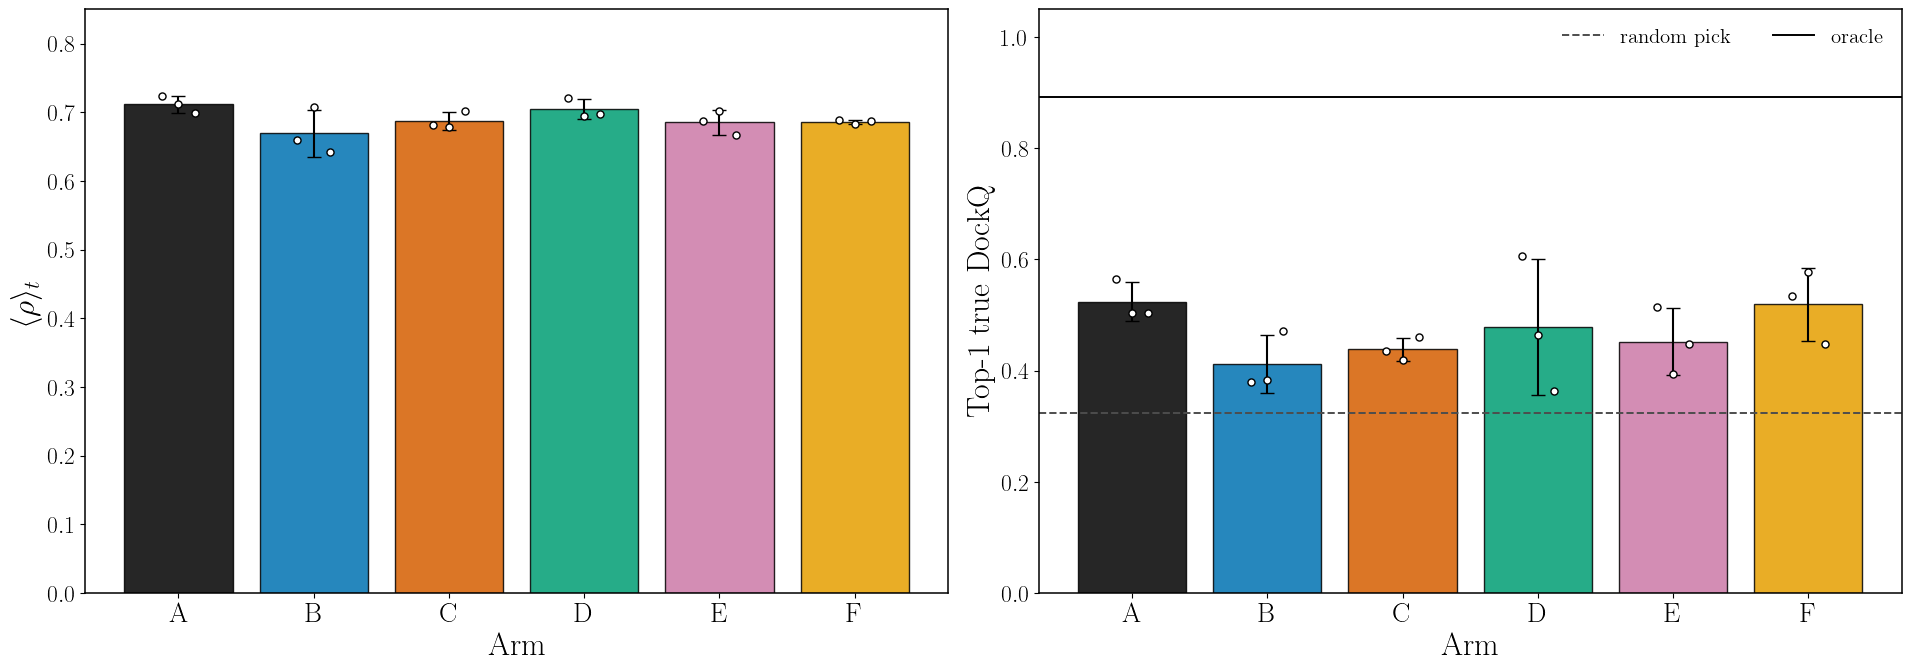

In [11]:
tstats = reference.groupby('target_id').true_target.agg(['mean', 'max'])
fig, axes = plt.subplots(1, 2, figsize=(19, 6.6), constrained_layout=True)
for ax, col, ylabel in [(axes[0], 'macro_rho', r'$\langle\rho\rangle_t$'), (axes[1], 'top1', 'Top-1 true DockQ')]:
    v = agg[(col, 'mean')].to_numpy(); e = agg[(col, 'std')].to_numpy()
    ax.bar(x, v, yerr=e, capsize=5, color=[ARM_COLOR[a] for a in ARMS], edgecolor='black', alpha=.85)
    for i, a in enumerate(ARMS):
        sv = metrics.loc[metrics.arm == a, col].to_numpy()
        ax.scatter(x[i] + np.linspace(-.12, .12, 3), sv, s=26, zorder=6, facecolors='white', edgecolors='black')
    ax.set_xticks(x, [SHORT[a] for a in ARMS], fontsize=20); ax.set_ylabel(ylabel); ax.set_xlabel('Arm')
axes[1].axhline(tstats['mean'].mean(), color='0.3', ls='--', lw=1.4, label='random pick')
axes[1].axhline(tstats['max'].mean(), color='black', lw=1.4, label='oracle')
axes[1].set_ylim(0, 1.05); axes[0].set_ylim(0, .85)
axes[1].legend(frameon=False, loc='upper right', ncol=2, fontsize=15)
save(fig, 'ranking_and_selection')

## Readout

In [12]:
def ms(arm, col, f='.4f'):
    return f"{agg.loc[arm, (col, 'mean')]:{f}} ± {agg.loc[arm, (col, 'std')]:{f}}"
lines = ['| arm | best val MSE | final val MSE | best epoch | ⟨ρ⟩ₜ | top-1 |', '|---|---|---|---|---|---|']
for a in ARMS:
    lines.append(f"| {ARM_LABEL[a]} | {ms(a, 'best')} | {ms(a, 'final')} | {ms(a, 'best_epoch', '.1f')} "
                 f"| {ms(a, 'macro_rho', '.3f')} | {ms(a, 'top1', '.3f')} |")
e = eff.set_index(['arm', 'metric'])
win = metrics.groupby('arm').best.mean().idxmin()
text = '\n'.join(lines) + f"""

- Constant predictor: **{CONST_MSE:.4f}**. Feature ladder (same features/split, old recipe): best
  **{lad_best.mean():.4f}**, final **{lad_final.mean():.4f}**.
- Lowest mean best validation MSE: **{ARM_LABEL[win]}**. Paired by target, no arm beats the control on MSE:
""" + '\n'.join(f"  - {ARM_LABEL[a]}: Δ = {e.loc[(a, 'mse'), 'mean']:+.4f} "
                f"[{e.loc[(a, 'mse'), 'lo']:+.4f}, {e.loc[(a, 'mse'), 'hi']:+.4f}], better on "
                f"{e.loc[(a, 'mse'), 'wins']}/12 targets" for a in ARMS[1:])
display(Markdown(text)); (EXPORT / 'readout.md').write_text(text)

| arm | best val MSE | final val MSE | best epoch | ⟨ρ⟩ₜ | top-1 |
|---|---|---|---|---|---|
| A control | 0.0485 ± 0.0015 | 0.0537 ± 0.0044 | 9.3 ± 2.1 | 0.712 ± 0.013 | 0.524 ± 0.035 |
| B detached | 0.0570 ± 0.0032 | 0.0607 ± 0.0045 | 10.0 ± 7.0 | 0.670 ± 0.034 | 0.412 ± 0.052 |
| C adversary | 0.0516 ± 0.0028 | 0.0987 ± 0.0004 | 3.0 ± 0.0 | 0.687 ± 0.013 | 0.438 ± 0.021 |
| D augment | 0.0504 ± 0.0029 | 0.0611 ± 0.0049 | 5.0 ± 1.7 | 0.705 ± 0.014 | 0.478 ± 0.122 |
| E balanced+EMA | 0.0524 ± 0.0003 | 0.0539 ± 0.0020 | 12.7 ± 8.7 | 0.685 ± 0.018 | 0.452 ± 0.060 |
| F combined | 0.0530 ± 0.0014 | 0.0652 ± 0.0206 | 13.3 ± 5.9 | 0.686 ± 0.003 | 0.519 ± 0.066 |

- Constant predictor: **0.0903**. Feature ladder (same features/split, old recipe): best
  **0.0716**, final **0.1305**.
- Lowest mean best validation MSE: **A control**. Paired by target, no arm beats the control on MSE:
  - B detached: Δ = -0.0061 [-0.0151, +0.0041], better on 3/12 targets
  - C adversary: Δ = -0.0017 [-0.0098, +0.0069], better on 4/12 targets
  - D augment: Δ = -0.0013 [-0.0061, +0.0031], better on 4/12 targets
  - E balanced+EMA: Δ = -0.0022 [-0.0088, +0.0059], better on 3/12 targets
  - F combined: Δ = -0.0028 [-0.0123, +0.0066], better on 6/12 targets

1250

## Interpretation and limitations

- **The rise is mostly gone in the control itself.** With fixed loss weights, range weighting, combined
  pooling, dropout 0.3 and a 20-epoch schedule, the best checkpoint moves from epoch 1--2 to epochs 7--11, best
  validation MSE falls from $\sim$0.072 to $\sim$0.049, and the end-of-training value ($\sim$0.054) stays far
  below the ladder's $\sim$0.13. Training DockQ MSE ends an order of magnitude higher than in the ladder, i.e.
  the control memorizes much less. Which of the changed settings is responsible is **not identified**: the
  adaptive loss shares (whose DockQ weight climbed to $\sim$260 as training DockQ MSE fell) are the leading
  suspect, but dropout, the shorter cosine schedule and the other changes moved at the same time.
- **None of the targeted interventions improved on that control.** D (augmentation) is closest on best MSE but
  rises more afterwards; E (balanced + EMA) gives the flattest, most seed-consistent curve at a slightly worse
  best value; B (detached) is worse than the control in all three seeds (0.057 vs 0.049; target-level
  interval still spans zero), so the encoder appears to need DockQ gradients; C diverged. Every paired
  interval against the control includes zero: these arms are at best ties, not improvements.
- **Less training fit did not mean better validation.** Across the non-diverged runs, the control fits the
  training targets most tightly *and* validates best; the memorization-targeted arms traded training fit for
  no validation gain.
- **C's failure is a method problem, not evidence against the idea.** Gradient reversal on an unbounded
  cross-entropy let the encoder win by inflating activations. A bounded objective (e.g. pushing the adversary's
  prediction toward uniform) would be needed to test target-invariance fairly.
- Twelve validation targets and three seeds; the paired intervals are wide, and this validation set has now
  informed several rounds of choices. The test split has not been touched.
- Graphs-seen axes treat every step as 16 graphs (each epoch's last batch is slightly smaller).